Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import io
from skimage.filters import threshold_otsu, threshold_li, threshold_triangle
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops
from scipy.stats import skew, kurtosis, entropy as scipy_entropy
import os

splits = {'train': 'data/train-00000-of-00001-8e16187b3ec7909d.parquet', 'test': 'data/test-00000-of-00001-68e8585122b38261.parquet'}
df = pd.read_parquet("hf://datasets/ahishamm/isic_binary_augmented/" + splits["train"])

def get_image_as_array(image_data):
  return np.array(Image.open(io.BytesIO(image_data['bytes'])))

## Step 1: RGB to Grayscale Conversion

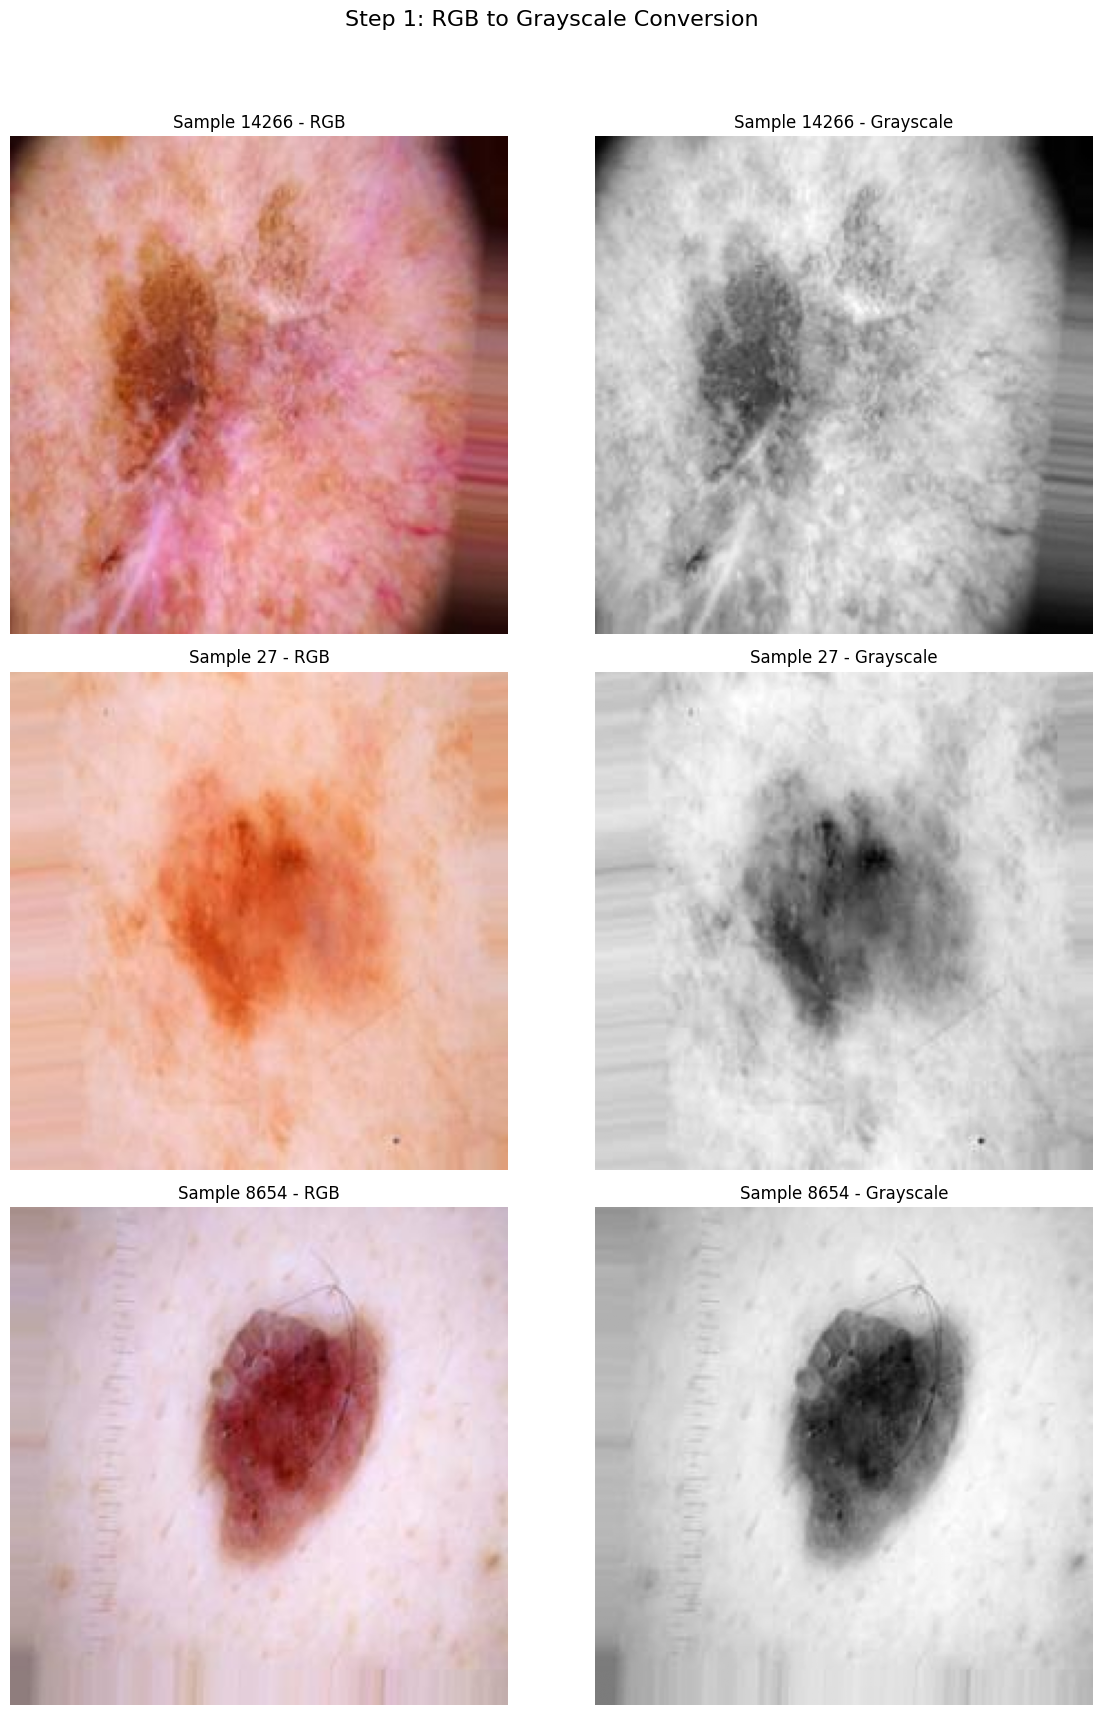

In [12]:
indices = [14266, 27, 8654]

plt.figure(figsize=(12, 18))
plt.suptitle("Step 1: RGB to Grayscale Conversion", fontsize=16)

for i, idx in enumerate(indices):
  rgb_img = get_image_as_array(df.iloc[idx]['image'])
  gray_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
  plt.subplot(3, 2, 2*i + 1)
  plt.imshow(rgb_img)
  plt.title(f"Sample {idx} - RGB")
  plt.axis('off')

  plt.subplot(3, 2, 2*i + 2)
  plt.imshow(gray_img, cmap='gray')
  plt.title(f"Sample {idx} - Grayscale")
  plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Step 2: Pre-processing

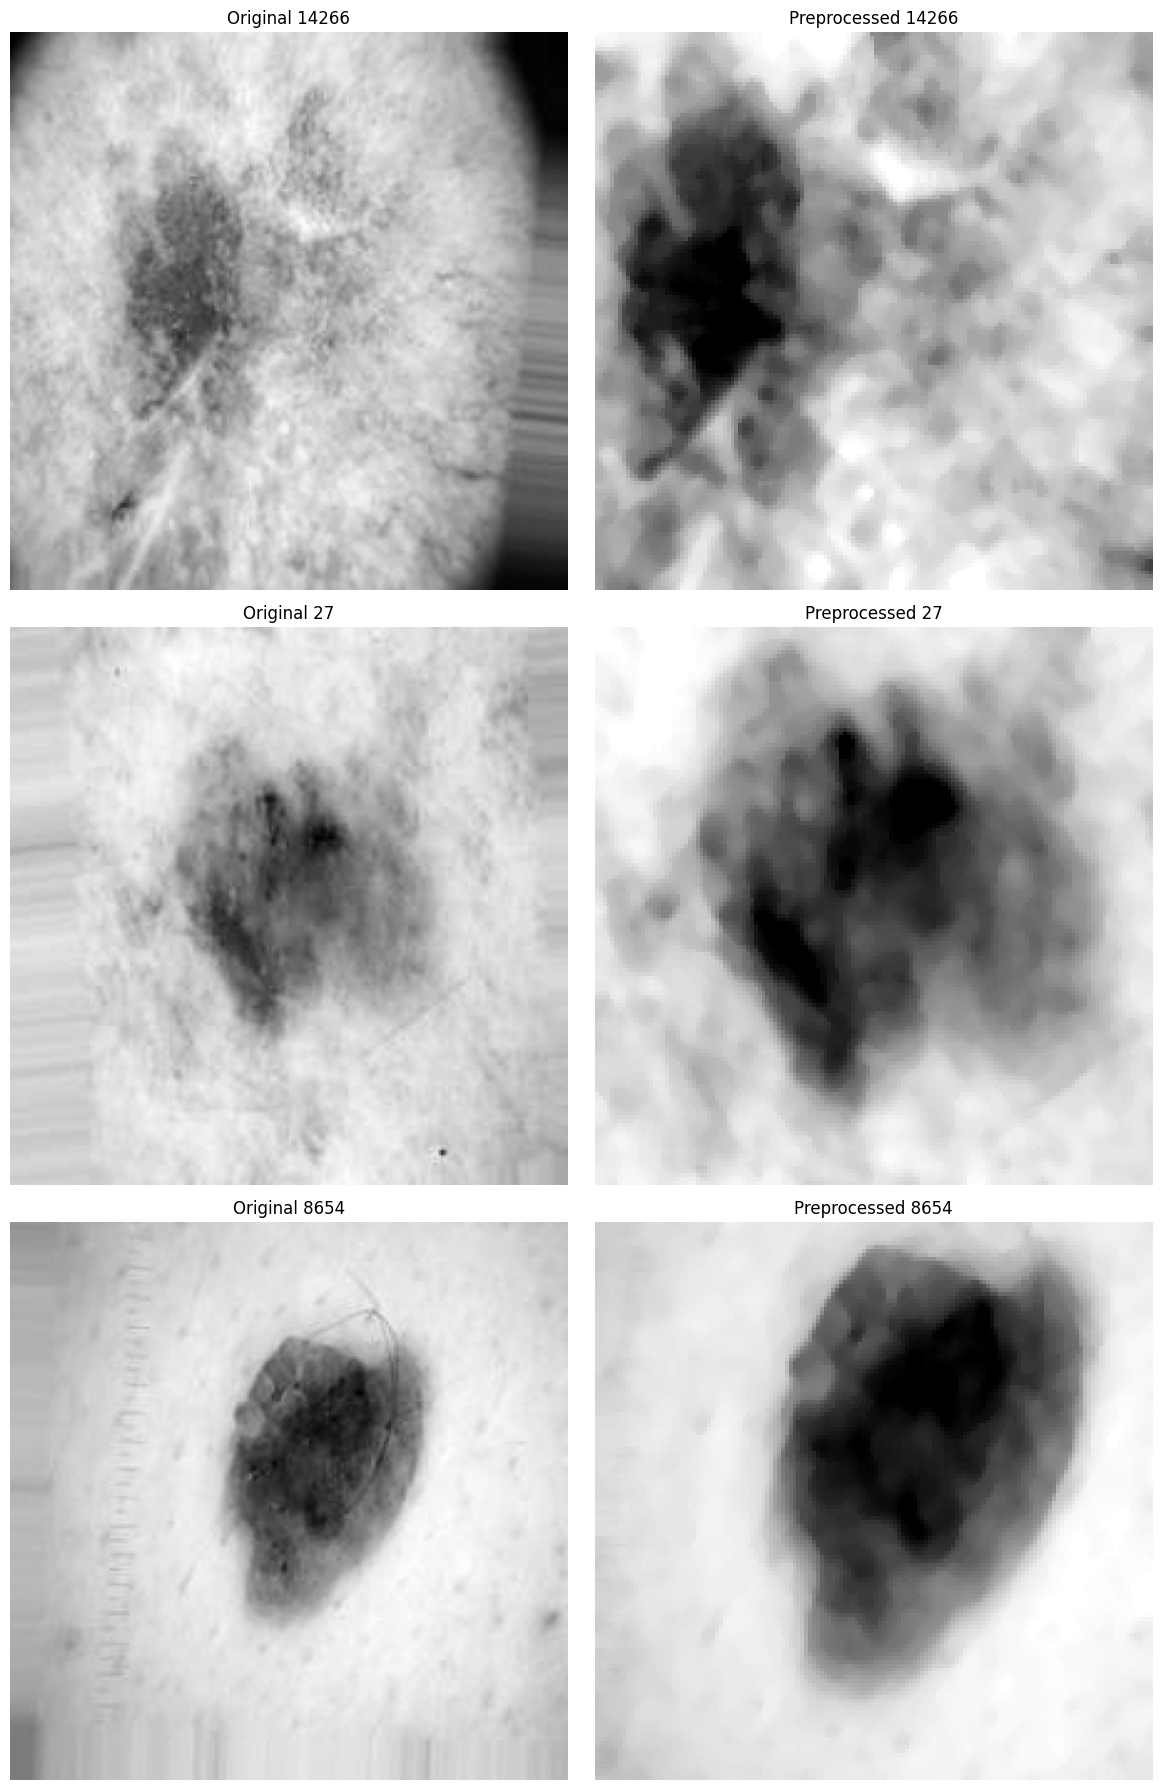

In [13]:
# crop
def crop_image(img, crop_percent=18):
  h, w = img.shape
  top = int(h * crop_percent / 100)
  bottom = h - top
  left = int(w * crop_percent / 100)
  right = w - left
  return img[top:bottom, left:right]

# contrast enhancement
def contrast_stretching(img):
  p2, p98 = np.percentile(img, (2, 98))
  rescale_img = np.clip(img, p2, p98)
  rescale_img = ((rescale_img - p2) / (p98 - p2) * 255).astype(np.uint8)
  return rescale_img

cropped_images = []
enhanced_images = []
final_preprocessed = []

plt.figure(figsize=(12, 18))
for i, idx in enumerate(indices):
  gray_img = cv2.cvtColor(get_image_as_array(df.iloc[idx]['image']), cv2.COLOR_RGB2GRAY)
  cropped = crop_image(gray_img)
  cropped_images.append(cropped)

  enhanced = contrast_stretching(cropped)
  enhanced_images.append(enhanced)

  blurred = cv2.medianBlur(enhanced, 5)
  final_preprocessed.append(blurred)

  plt.subplot(3, 2, 2*i + 1)
  plt.imshow(gray_img, cmap='gray')
  plt.title(f"Original {idx}")
  plt.axis('off')

  plt.subplot(3, 2, 2*i + 2)
  plt.imshow(blurred, cmap='gray')
  plt.title(f"Preprocessed {idx}")
  plt.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Thresholding

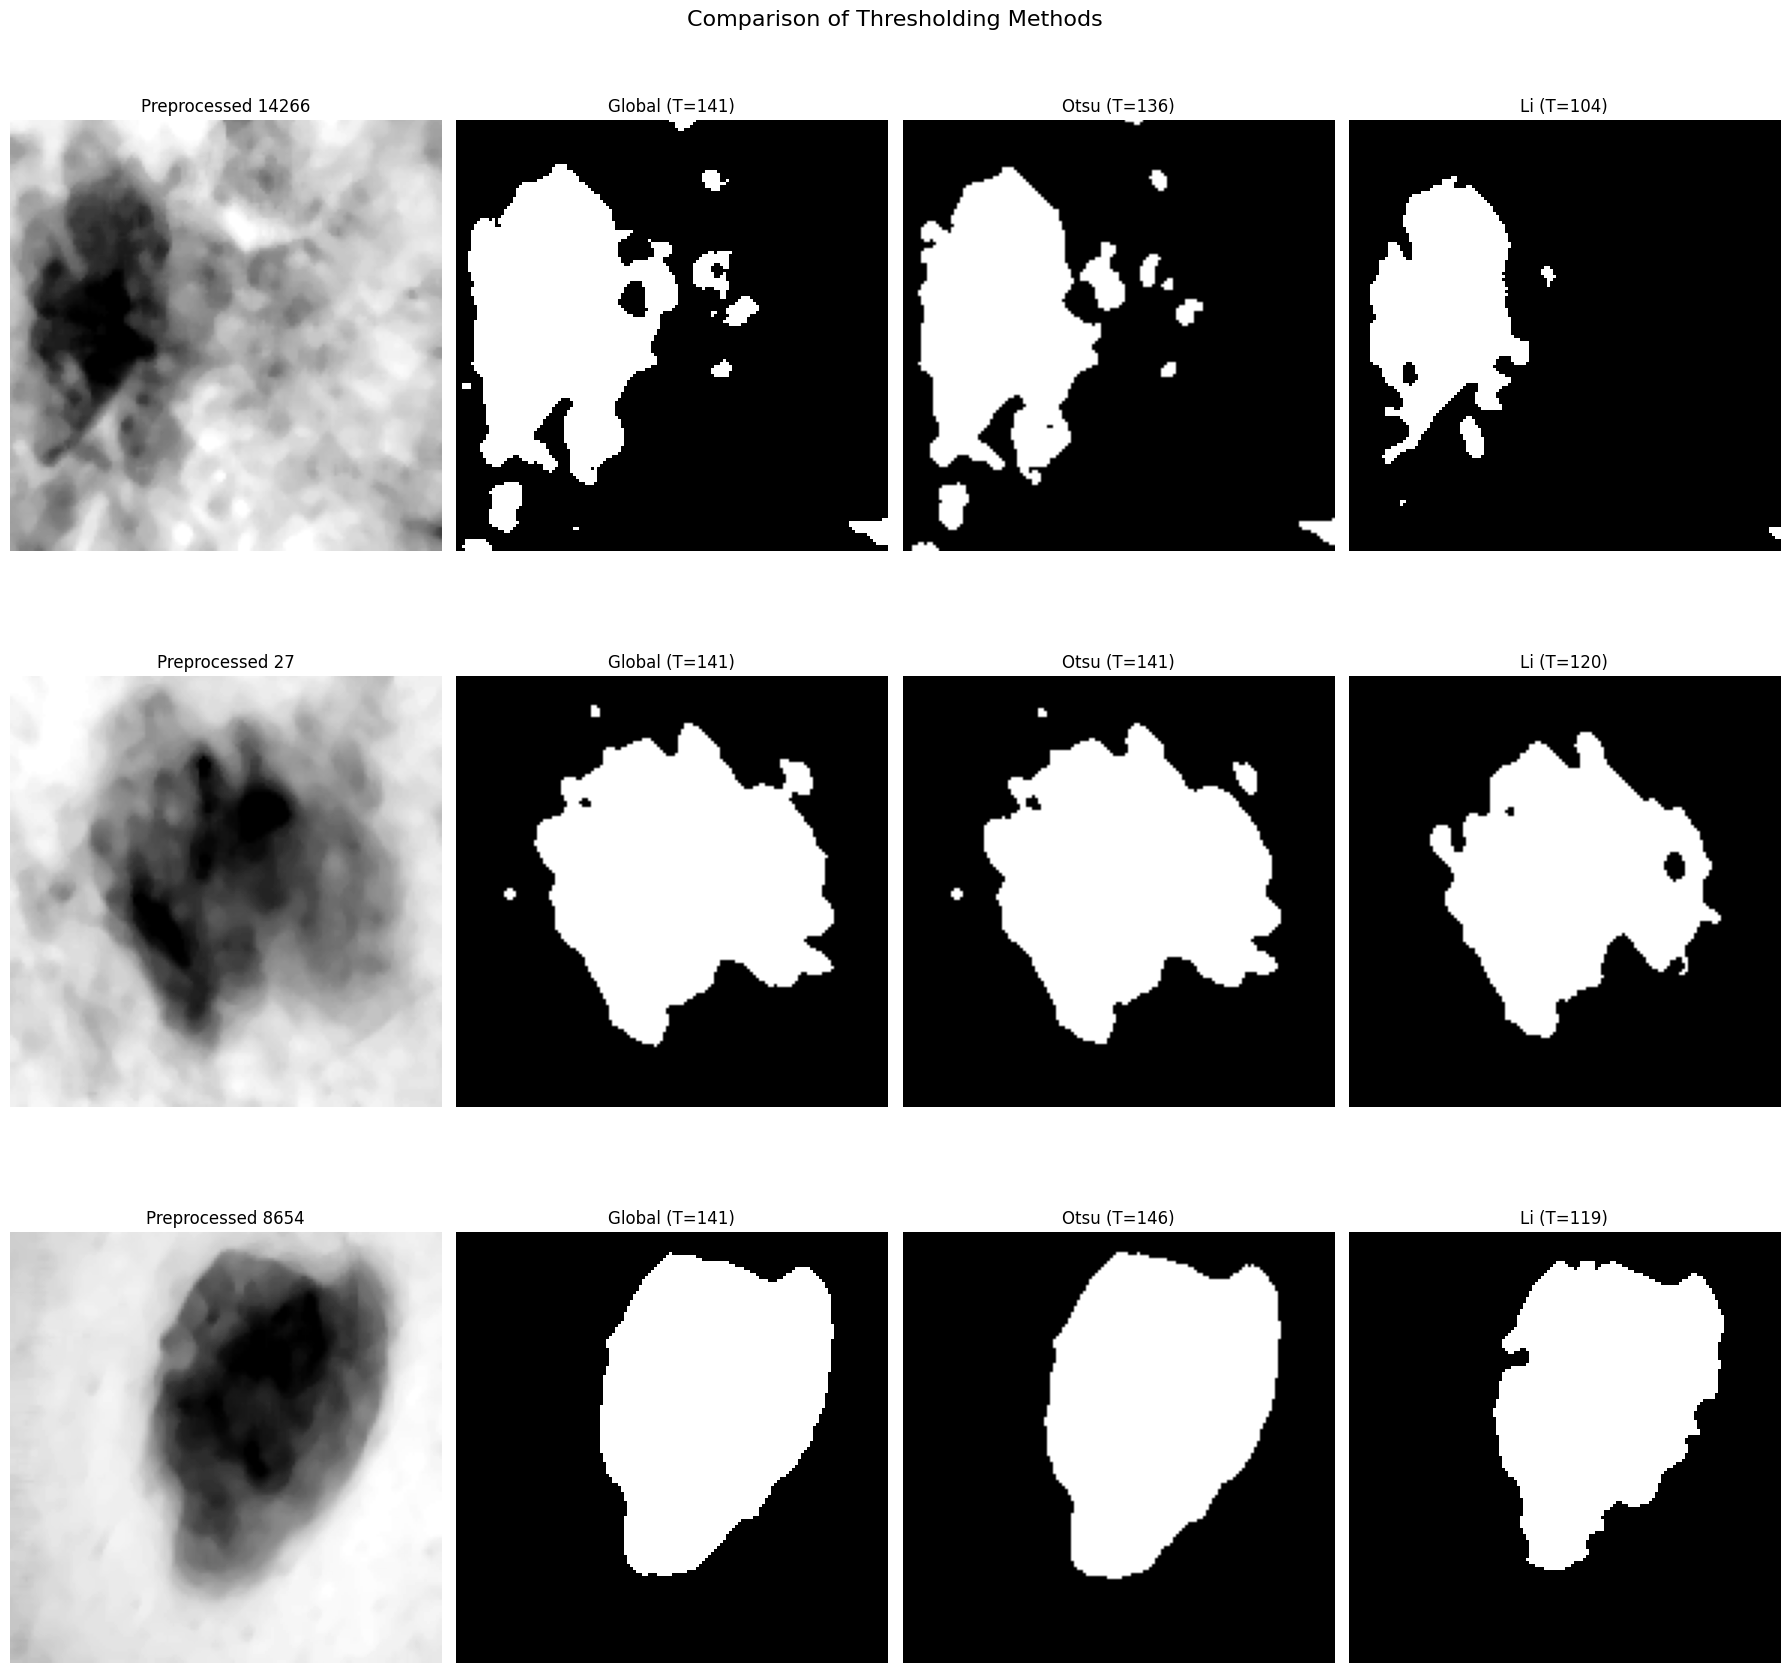

In [14]:
def apply_thresholding_methods(img):
  # 1. Global Thresholding
  global_val = 141
  _, thresh_global = cv2.threshold(img, global_val, 255, cv2.THRESH_BINARY_INV)

  # 2. Otsu's Thresholding
  otsu_val = threshold_otsu(img)
  thresh_otsu = (img < otsu_val).astype(np.uint8) * 255

  # 3. Li's Thresholding
  li_val = threshold_li(img)
  thresh_li = (img < li_val).astype(np.uint8) * 255

  return (thresh_global, global_val), (thresh_otsu, otsu_val), (thresh_li, li_val)

plt.figure(figsize=(18, 18))
plt.suptitle("Comparison of Thresholding Methods", fontsize=16)

results_table = []

for i, idx in enumerate(indices):
  raw_img = get_image_as_array(df.iloc[idx]['image'])
  gray = cv2.cvtColor(raw_img, cv2.COLOR_RGB2GRAY)
  cropped = crop_image(gray)
  enhanced = contrast_stretching(cropped)
  blurred = cv2.medianBlur(enhanced, 5)

  (t_global, v_global), (t_otsu, v_otsu), (t_li, v_li) = apply_thresholding_methods(blurred)
  results_table.append([idx, round(v_global, 2), round(v_otsu, 2)])

  plt.subplot(3, 4, 4*i + 1)
  plt.imshow(blurred, cmap='gray')
  plt.title(f"Preprocessed {idx}")
  plt.axis('off')

  plt.subplot(3, 4, 4*i + 2)
  plt.imshow(t_global, cmap='gray')
  plt.title(f"Global (T={v_global})")
  plt.axis('off')

  plt.subplot(3, 4, 4*i + 3)
  plt.imshow(t_otsu, cmap='gray')
  plt.title(f"Otsu (T={int(v_otsu)})")
  plt.axis('off')

  plt.subplot(3, 4, 4*i + 4)
  plt.imshow(t_li, cmap='gray')
  plt.title(f"Li (T={int(v_li)})")
  plt.axis('off')

plt.tight_layout()
plt.show()

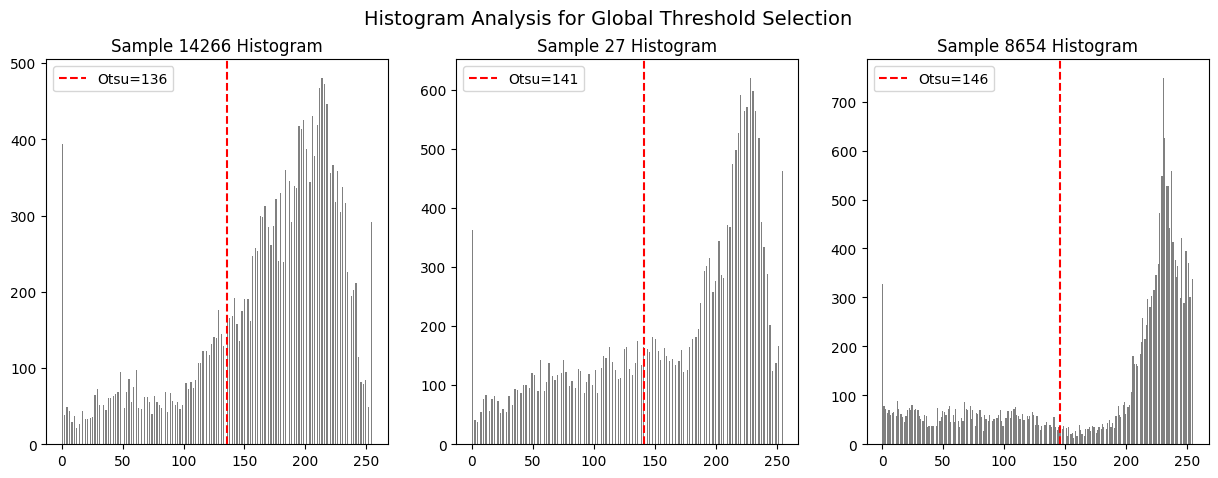

Based on the histograms, a fixed threshold for Global Thresholding has been selected: 141


In [19]:
# Histogram Analysis for Global Threshold Selection
plt.figure(figsize=(15, 5))
plt.suptitle("Histogram Analysis for Global Threshold Selection", fontsize=14)

global_candidates = []

for i, idx in enumerate(indices): # Use the same 3 indices as defined earlier
    # Obtain the image after all preprocessing steps
    raw_img = get_image_as_array(df.iloc[idx]['image'])
    gray = cv2.cvtColor(raw_img, cv2.COLOR_RGB2GRAY)
    proc = cv2.medianBlur(contrast_stretching(crop_image(gray)), 5)

    plt.subplot(1, 3, i+1)
    plt.hist(proc.ravel(), bins=256, color='gray')

    # Calculate Otsu as a guide to where the boundary should approximately be
    val_otsu = threshold_otsu(proc)
    global_candidates.append(val_otsu)

    plt.axvline(val_otsu, color='r', linestyle='--', label=f'Otsu={int(val_otsu)}')
    plt.title(f"Sample {idx} Histogram")
    plt.legend()

plt.show()

# Calculate the average Otsu value across the sample to be used as a fixed Global Threshold
chosen_global_val = int(np.mean(global_candidates))
print(f"Based on the histograms, a fixed threshold for Global Thresholding has been selected: {chosen_global_val}")

## Step 4: Post-Processing

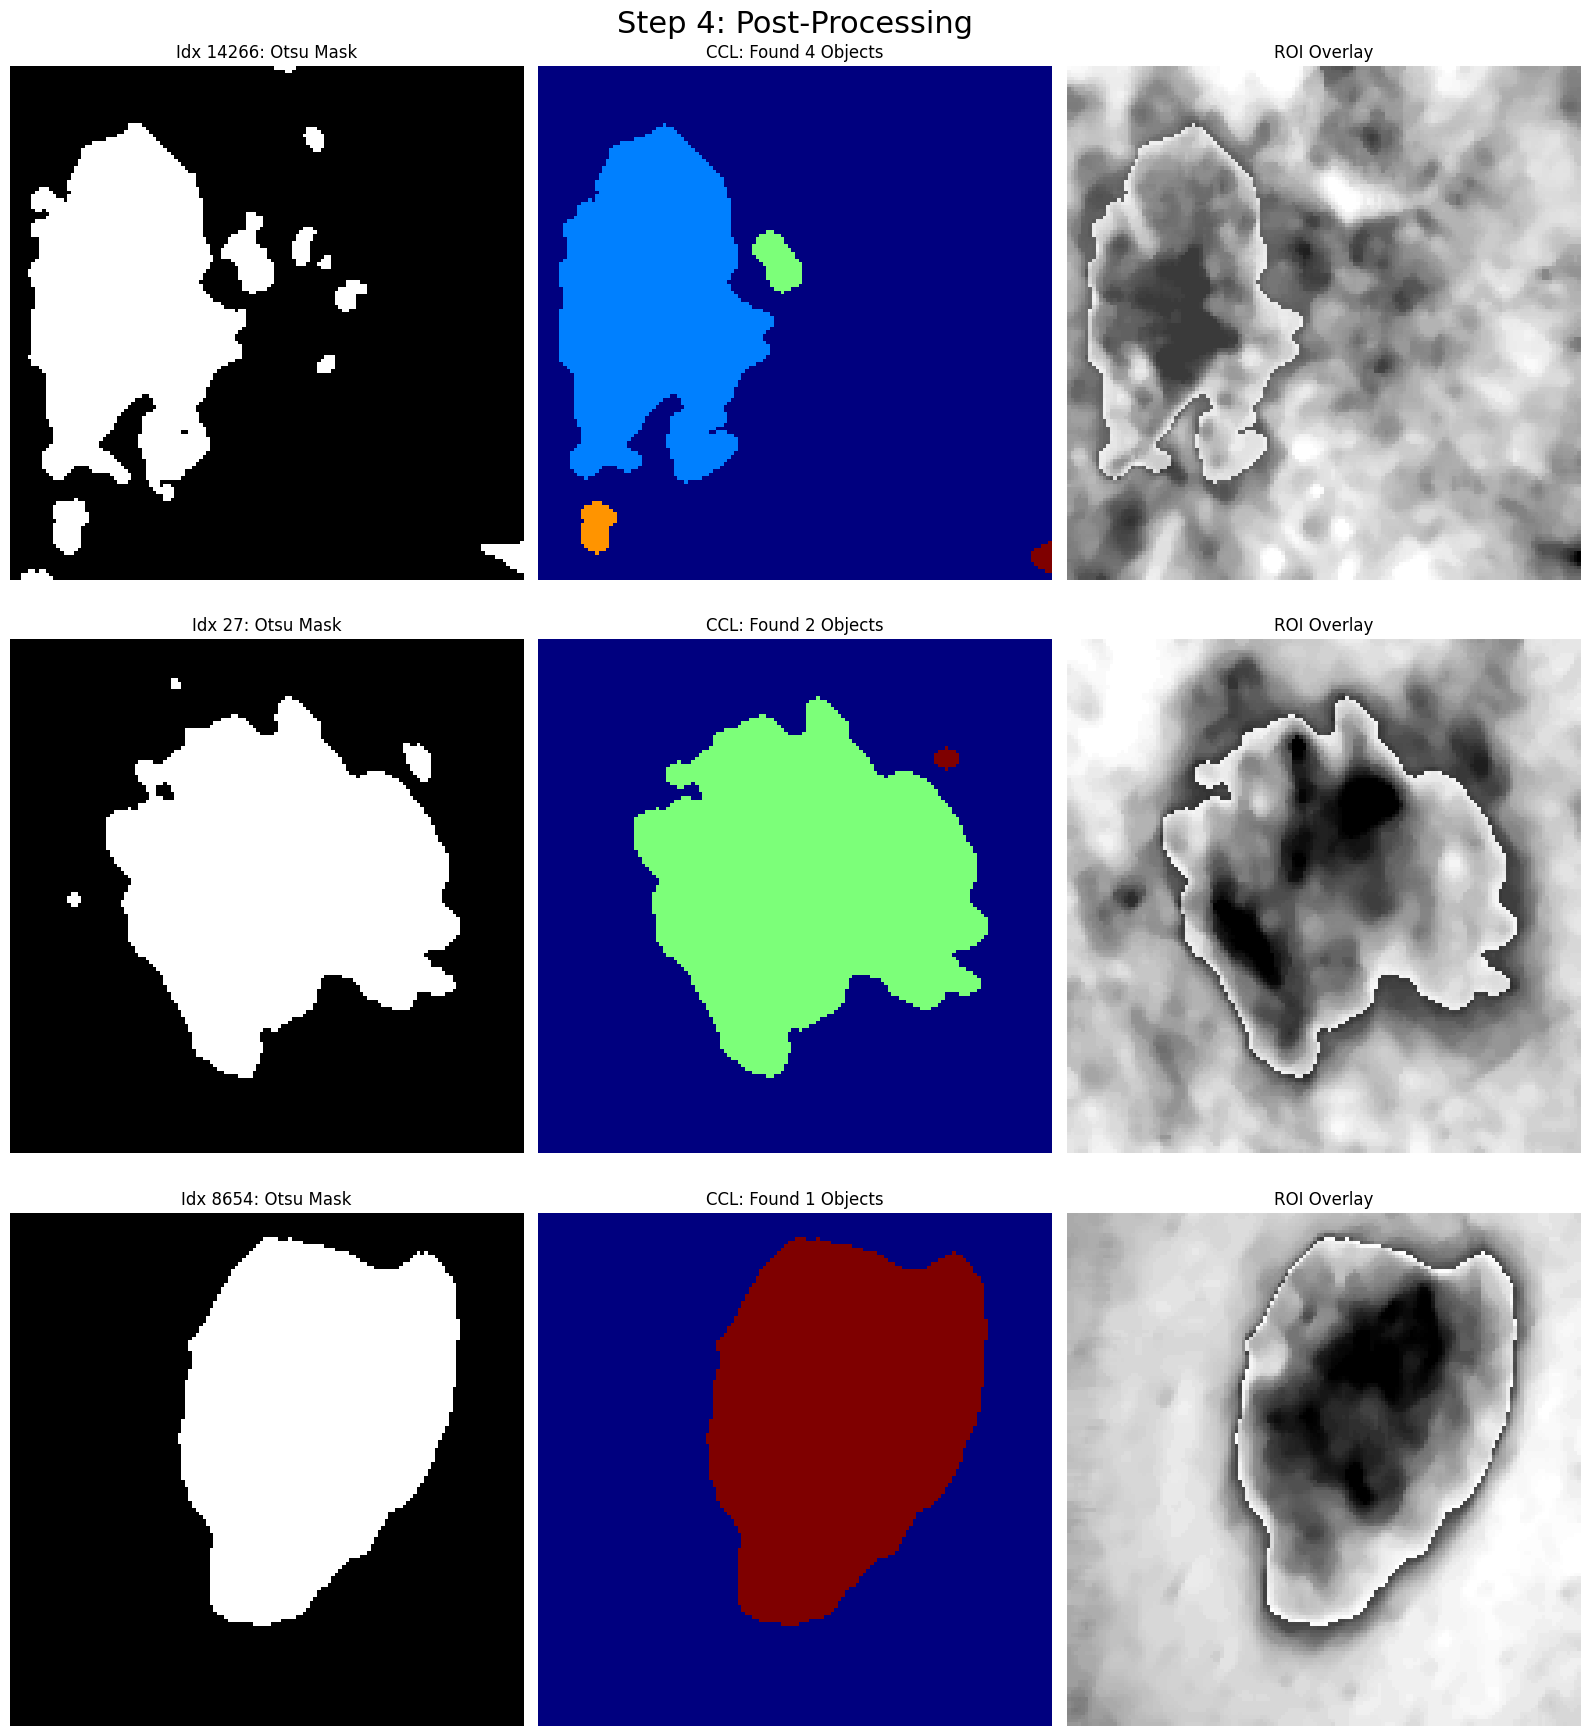

In [16]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

final_roi_masks = []
component_counts = []

plt.figure(figsize=(16, 18))
plt.suptitle("Step 4: Post-Processing", fontsize=22)

for i, idx in enumerate(indices):
  raw_img = get_image_as_array(df.iloc[idx]['image'])
  gray = cv2.cvtColor(raw_img, cv2.COLOR_RGB2GRAY)
  cropped = crop_image(gray)
  enhanced = contrast_stretching(cropped)
  blurred = cv2.medianBlur(enhanced, 5)

  val = threshold_otsu(blurred)
  binary_mask = (blurred < val).astype(np.uint8) * 255
  morphed = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(morphed, connectivity=8)

  largest_label_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
  final_mask = (labels == largest_label_idx).astype(np.uint8) * 255

  final_roi_masks.append(final_mask)
  component_counts.append(num_labels - 1)

  plt.subplot(3, 3, 3*i + 1)
  plt.imshow(binary_mask, cmap='gray')
  plt.title(f'Idx {idx}: Otsu Mask')
  plt.axis('off')

  plt.subplot(3, 3, 3*i + 2)
  plt.imshow(labels, cmap='jet')
  plt.title(f'CCL: Found {num_labels-1} Objects')
  plt.axis('off')

  plt.subplot(3, 3, 3*i + 3)
  overlay = cv2.addWeighted(blurred, 0.7, final_mask, 0.3, 0)
  plt.imshow(overlay, cmap='gray')
  plt.title(f'ROI Overlay')
  plt.axis('off')

plt.tight_layout()
plt.show()


## Step 5: Feature Extraction

In [17]:
def get_statistical_features(roi_pixels):
  if len(roi_pixels) == 0:
    return [0] * 10

  mean_val = np.mean(roi_pixels)
  std_val = np.std(roi_pixels)
  var_val = np.var(roi_pixels)
  min_val = np.min(roi_pixels)
  max_val = np.max(roi_pixels)
  median_val = np.median(roi_pixels)
  skew_val = skew(roi_pixels)
  kurt_val = kurtosis(roi_pixels)
  energy = np.sum(roi_pixels.astype(float)**2)
  hist, _ = np.histogram(roi_pixels, bins=256, range=(0, 255), density=True)
  ent_val = scipy_entropy(hist + 1e-7)

  return [mean_val, std_val, var_val, min_val, max_val, median_val, skew_val, kurt_val, energy, ent_val]

def get_glcm_features(img, mask):
  masked_img = img.copy()
  masked_img[mask == 0] = 0
  quantized_img = (masked_img // 8).astype(np.uint8)

  distances = [1]
  angles = [0]
  glcm = graycomatrix(quantized_img, distances=distances, angles=angles, levels=32, symmetric=True, normed=True)

  contrast = graycoprops(glcm, 'contrast')[0, 0]
  dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
  homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
  energy = graycoprops(glcm, 'energy')[0, 0]
  correlation = graycoprops(glcm, 'correlation')[0, 0]
  asm = graycoprops(glcm, 'ASM')[0, 0]

  return [contrast, dissimilarity, homogeneity, energy, correlation, asm]

all_features = []

for idx in range(len(df)):
  raw_img = get_image_as_array(df.iloc[idx]['image'])
  label = df.iloc[idx]['label']
  # image_id = idx # or use actual filename if available
  gray = cv2.cvtColor(raw_img, cv2.COLOR_RGB2GRAY)
  prep = cv2.medianBlur(contrast_stretching(crop_image(gray)), 5)
  val = threshold_otsu(prep)
  binary_mask = (prep < val).astype(np.uint8) * 255
  kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
  morphed = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
  num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(morphed)

  if num_labels <= 1: continue

  largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
  final_mask = (labels == largest_idx).astype(np.uint8) * 255

  roi_pixels = prep[final_mask == 255]
  stat_feats = get_statistical_features(roi_pixels)

  prop = regionprops(final_mask)[0]
  circularity = (4 * np.pi * prop.area) / (prop.perimeter**2) if prop.perimeter > 0 else 0
  aspect_ratio = prop.major_axis_length / prop.minor_axis_length if prop.minor_axis_length > 0 else 0

  shape_feats = [
      prop.area, prop.perimeter, circularity, prop.eccentricity,
      prop.solidity, prop.extent, prop.major_axis_length,
      prop.minor_axis_length, aspect_ratio, prop.convex_area,
      prop.equivalent_diameter
  ]

  glcm_feats = get_glcm_features(prep, final_mask)
  row = [idx, label] + stat_feats + shape_feats + glcm_feats
  all_features.append(row)

columns = [
    'image_id', 'label',
    'mean', 'std', 'variance', 'min', 'max', 'median', 'skewness', 'kurtosis', 'entropy', 'energy_stat',
    'area', 'perimeter', 'circularity', 'eccentricity', 'solidity', 'extent', 'major_axis', 'minor_axis', 'aspect_ratio', 'convex_area', 'equiv_diameter',
    'contrast', 'dissimilarity', 'homogeneity', 'energy_glcm', 'correlation', 'asm'
]

features_df = pd.DataFrame(all_features, columns=columns)
features_df.to_csv("skin_lesion_features.csv", index=False)